# 🎾 ATP Match Prediction — Resumen didáctico

> Notebook de aprendizaje (ítem **N1** del `docs/ROADMAP.md`). Reúsa el código de
> `src/` para explicar, paso a paso, **los conceptos básicos** del proyecto sin
> tocar la parte web.

**Qué vas a aprender aquí:**

1. **ELO** — la matemática del rating dinámico: expectativa logística + ecuación de actualización.
2. **ELO híbrido** — combinar rendimiento general y por superficie.
3. **Simetrización** — por qué un dataset de partidos tal cual está *roto* para ML (label leakage) y cómo se arregla.
4. **Las features** — el vector que ve el modelo y por qué son *diferencias*.
5. **CV temporal con embargo** — cómo validar sin hacer trampa con el futuro.
6. **Lectura honesta de métricas** — por qué `accuracy` engaña y qué dicen log-loss, Brier, AUC y la learning curve.

Cada sección: **narrativa → celda ejecutable → qué observar**.

---
*Ejecuta las celdas en orden. Requiere el entorno del proyecto (`pip install -r requirements.txt`) y la carpeta `data/`.*

## 0 · Preparación del entorno

El notebook vive en `notebooks/`, pero el código (`src/`) y los datos (`data/`)
cuelgan de la raíz del repo. La siguiente celda fija el directorio de trabajo en
la raíz para que los imports y las rutas relativas funcionen igual que en `main.py`.

In [1]:
import os, sys

# Subir a la raíz del repo si estamos dentro de notebooks/
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
ROOT = os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 4)
print("Raíz del proyecto:", ROOT)
print("¿Existe data/? ", os.path.isdir("data"))
print("¿Existe src/?  ", os.path.isdir("src"))

Raíz del proyecto: /Users/luissantra/Projects/ATP Prediction/.claude/worktrees/festive-wilbur-58ce70
¿Existe data/?  True
¿Existe src/?   True


## 1 · ELO — rating dinámico

El sistema **ELO** (Arpad Elo, ajedrez) asigna a cada jugador un número que sube
cuando gana y baja cuando pierde. Dos ecuaciones lo gobiernan.

### 1.1 Expectativa (probabilidad esperada)

Probabilidad teórica de que **A** gane a **B**, en función de la diferencia de
ratings. Es una **función logística**:

$$E_A = \frac{1}{1 + 10^{(R_B - R_A)/400}}$$

- Diferencia 0 → 50% / 50%.
- $R_A - R_B = 400$ → A gana ~91%.

La constante **400** define la escala: cada 400 puntos = 10× más probable ganar.

  ventaja de A =    0 ELO  ->  P(gana A) = 50.0%
  ventaja de A =  100 ELO  ->  P(gana A) = 64.0%
  ventaja de A =  200 ELO  ->  P(gana A) = 76.0%
  ventaja de A =  400 ELO  ->  P(gana A) = 90.9%
  ventaja de A =  800 ELO  ->  P(gana A) = 99.0%


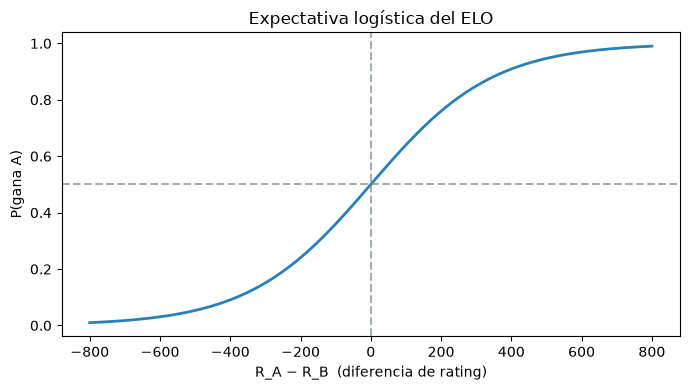

In [2]:
from src.elo import calcular_expectativa

for dif in [0, 100, 200, 400, 800]:
    e = calcular_expectativa(1500 + dif, 1500)   # A está 'dif' puntos por encima
    print(f"  ventaja de A = {dif:>4} ELO  ->  P(gana A) = {e:.1%}")

# La curva logística completa
difs = np.linspace(-800, 800, 200)
probs = [calcular_expectativa(1500 + d, 1500) for d in difs]
plt.figure(figsize=(7, 4))
plt.plot(difs, probs, color="#2980b9", lw=2)
plt.axhline(0.5, ls="--", color="#7f8c8d", alpha=.7)
plt.axvline(0, ls="--", color="#7f8c8d", alpha=.7)
plt.title("Expectativa logística del ELO")
plt.xlabel("R_A − R_B  (diferencia de rating)")
plt.ylabel("P(gana A)")
plt.tight_layout(); plt.show()

**Qué observar:** la probabilidad nunca es 0 ni 1 — el tenis siempre deja margen
a la sorpresa. La pendiente es máxima cerca de 0 (partidos parejos = más
incertidumbre) y se aplana en los extremos.

### 1.2 Actualización tras el partido

$$R'_A = R_A + K\,(S_A - E_A)$$

- $S_A$ = resultado real (1 gana, 0 pierde).
- $E_A$ = lo que esperábamos.
- $K$ = tasa de aprendizaje (aquí **32**).

La clave es $S_A - E_A$, la **sorpresa**: si el favorito gana lo esperado, apenas
se mueve; si gana el *underdog*, el ajuste es grande.

In [3]:
from src.elo import actualizar_ratings

# Caso 1: gana el gran favorito (esperábamos 0.90)
favorito, rival = 1900, 1500
na, nb = actualizar_ratings(favorito, rival, resultado_A=1)
print(f"Gana favorito  : {favorito} -> {na:.1f}  (+{na-favorito:.1f})   poca sorpresa")

# Caso 2: el underdog da la campanada
na, nb = actualizar_ratings(rival, favorito, resultado_A=1)
print(f"Gana underdog  : {rival} -> {na:.1f}  (+{na-rival:.1f})  ¡gran ajuste!")

Gana favorito  : 1900 -> 1902.9  (+2.9)   poca sorpresa
Gana underdog  : 1500 -> 1529.1  (+29.1)  ¡gran ajuste!


**Qué observar:** mismo K=32, ajustes muy distintos. El ELO premia las victorias
*informativas* (las inesperadas) y descuenta las rutinarias. Nota: `actualizar_ratings`
devuelve **full-precision** (sin redondear) — redondear en cada update acumularía
error (ítem M1 del roadmap).

## 2 · ELO histórico e híbrido

`calcular_elos_historicos` recorre **todos los partidos en orden cronológico**,
arrancando a cada jugador en 1500 y actualizando tras cada partido. Crucial:
guarda el rating **previo** al partido → no hay fuga de información del futuro.

Además mantiene un ELO **por superficie** (Clay/Grass/Hard). El **ELO híbrido**
mezcla ambos:

$$\text{ELO}_{hib} = w\cdot\text{ELO}_{general} + (1-w)\cdot\text{ELO}_{superficie}, \quad w=0.5$$

Esto captura a los *especialistas* (p. ej. un jugador medio en general pero
temible en tierra) que el ranking ATP oficial suele subestimar.

In [4]:
from src.features import elo_hibrido

# Especialista de tierra: general flojo, superficie altísimo
print("Híbrido (general=1600, clay=2000):", elo_hibrido(1600, 2000))
print("Híbrido (general=1800, clay=1800):", elo_hibrido(1800, 1800))
print("-> dos jugadores con misma media pero perfiles opuestos")

Híbrido (general=1600, clay=2000): 1800.0
Híbrido (general=1800, clay=1800): 1800.0
-> dos jugadores con misma media pero perfiles opuestos


In [5]:
from src.elo import calcular_elos_historicos

# Usamos un tramo reciente para que sea rápido y didáctico.
AÑOS = [2022, 2023, 2024, 2025, 2026]
df_completo, elo_general, elo_superficie = calcular_elos_historicos("data", AÑOS)

print(f"\nPartidos procesados: {len(df_completo)}")
top = sorted(elo_general.items(), key=lambda kv: kv[1], reverse=True)[:10]
print("\nTop 10 ELO general (fin de periodo):")
for i, (j, r) in enumerate(top, 1):
    print(f"  {i:2d}. {j:<24} {r:7.1f}")

-> Procesando 12070 partidos cronológicamente...



Partidos procesados: 12070

Top 10 ELO general (fin de periodo):
   1. Jannik Sinner             2255.3
   2. Carlos Alcaraz            2181.4
   3. Novak Djokovic            2011.1
   4. Alexander Zverev          1882.9
   5. Felix Auger-Aliassime     1880.9
   6. Daniil Medvedev           1875.3
   7. Alex de Minaur            1875.1
   8. Alexander Bublik          1869.7
   9. Jack Draper               1868.4
  10. Lorenzo Musetti           1820.0


**Qué observar:** el DataFrame `df_completo` queda enriquecido con columnas
`elo_winner`, `elo_loser`, `*_general`, `*_sup` — todas **pre-partido**. Esa es la
materia prima de las features.

## 3 · Simetrización — el problema del *label leakage*

Los datos vienen como `[winner_*, loser_*]`. Si definimos la feature como
`winner_rank − loser_rank` y la etiqueta como "ganó el winner", **la etiqueta
siempre es 1**. El modelo aprendería la regla trivial *"la fila existe → ganó"*,
inútil para predecir un partido futuro donde no sabes quién gana.

**Solución (simetrización):** para cada partido lanzamos una moneda:

- cara → Jugador A = ganador, label = 1
- cruz → Jugador A = perdedor, label = 0

y siempre calculamos las diferencias como **A − B**. Resultado: dataset balanceado
~50/50 donde el modelo debe aprender la *frontera real* de decisión.

In [6]:
from src.data_processing import preparar_datos_entrenamiento

df_features = preparar_datos_entrenamiento(df_completo)

print("Forma:", df_features.shape)
print("\nBalance de la etiqueta (debe rondar 0.5):")
print(df_features["label"].value_counts(normalize=True).round(3))
df_features.head()

Forma: (12070, 9)

Balance de la etiqueta (debe rondar 0.5):
label
0    0.501
1    0.499
Name: proportion, dtype: float64


,year,tourney_date,surface,diff_elo_general,diff_elo_sup,diff_rank,is_unranked,diff_age,label
0,2022,20220103,Hard,0.0,0.0,-206.0,0,2.847,1
1,2022,20220103,Hard,0.0,0.0,71.0,0,-6.283,0
2,2022,20220103,Hard,0.0,0.0,-138.0,0,3.797,1
3,2022,20220103,Hard,0.0,0.0,-9.0,0,-0.479,1
4,2022,20220103,Hard,0.0,0.0,65.0,0,-3.699,0


**Qué observar:** `label` ~50/50 (semilla fija `seed=42` → reproducible). Las
columnas `diff_*` pueden ser positivas o negativas: ya no hay un "lado ganador"
fijo. Esto es lo que rompe el leakage.

## 4 · Las features — qué ve el modelo

La **fuente única de verdad** es `src/features.py` (lista `FEATURES`). Tanto el
entrenamiento como la inferencia construyen el vector desde ahí, para evitar
*train/serve skew* (que el modelo se entrene con un orden/representación y se
sirva con otro).

Todas son **diferencias A − B**, así que el signo indica a quién favorece el factor.

In [7]:
from src.features import FEATURES, RANK_CAP

descripciones = {
    "diff_elo_general": "Δ ELO general (forma global)",
    "diff_elo_sup":     "Δ ELO de la superficie del partido",
    "diff_rank":        "Δ ranking ATP (capeado a 250)",
    "is_unranked":      "indicador wildcard/qualifier sin ranking (∈ -1,0,1)",
    "diff_age":         "Δ edad",
}
print(f"FEATURES ({len(FEATURES)}):")
for f in FEATURES:
    print(f"  • {f:<18} {descripciones[f]}")
print(f"\nRANK_CAP = {RANK_CAP}   (rank peor que 250 se trata como 250 → evita outliers)")

FEATURES (5):
  • diff_elo_general   Δ ELO general (forma global)
  • diff_elo_sup       Δ ELO de la superficie del partido
  • diff_rank          Δ ranking ATP (capeado a 250)
  • is_unranked        indicador wildcard/qualifier sin ranking (∈ -1,0,1)
  • diff_age           Δ edad

RANK_CAP = 250   (rank peor que 250 se trata como 250 → evita outliers)


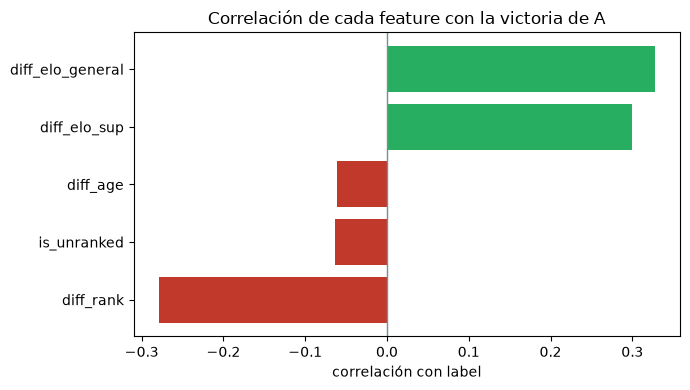

In [8]:
# ¿Cómo se relacionan las features con ganar (label)? Correlación rápida.
corr = df_features[FEATURES + ["label"]].corr()["label"].drop("label").sort_values()
plt.figure(figsize=(7, 4))
colors = ["#c0392b" if v < 0 else "#27ae60" for v in corr.values]
plt.barh(corr.index, corr.values, color=colors)
plt.axvline(0, color="#7f8c8d", lw=1)
plt.title("Correlación de cada feature con la victoria de A")
plt.xlabel("correlación con label")
plt.tight_layout(); plt.show()

**Qué observar:** `diff_elo_*` y `diff_rank` son los que más correlacionan (la
señal vive sobre todo ahí). Nota: el modelo final es **lineal** (regresión
logística), así que esta correlación es buena intuición de su peso real. El
roadmap pasó de 6 → 8 → **5 features**: tras un estudio de *permutation importance*
+ ablación se podaron `diff_h2h`, `diff_form` y `tourney_level_num` (importancia
~0; el ELO ya absorbe la forma y el H2H es débil tras controlar por ELO).

## 5 · Validación cruzada temporal con embargo

Con datos temporales **no puedes** usar K-Fold aleatorio: meterías partidos
futuros en el train para predecir el pasado (leakage). Se usa `TimeSeriesSplit`:
cada fold entrena con el pasado y valida con el futuro inmediato.

Pero queda una **fuga blanda**: el último partido de train y el primero de val
pueden estar a horas (mismo torneo) y comparten estado ELO/H2H casi idéntico. El
**embargo** purga del train las filas a < N días del inicio de validación.

Folds (train con embargo de 7 días → val):
  fold 0: train= 1848  val= 1988
  fold 1: train= 3915  val= 1988
  fold 2: train= 5913  val= 1988
  fold 3: train= 7869  val= 1988
  fold 4: train= 9893  val= 1988


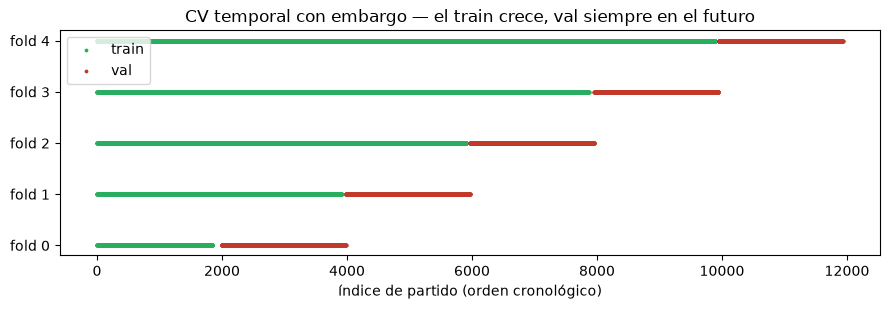

In [9]:
from src.cv import purged_time_series_splits

df_train = df_features[df_features["year"] < 2026].reset_index(drop=True)
dates = df_train["tourney_date"].values

print("Folds (train con embargo de 7 días → val):")
splits = list(purged_time_series_splits(dates, n_splits=5, embargo_days=7))

plt.figure(figsize=(9, 3.2))
for i, (tr, va) in enumerate(splits):
    plt.scatter(tr, [i]*len(tr), s=3, color="#27ae60", label="train" if i == 0 else "")
    plt.scatter(va, [i]*len(va), s=3, color="#c0392b", label="val" if i == 0 else "")
    print(f"  fold {i}: train={len(tr):>5}  val={len(va):>5}")
plt.yticks(range(len(splits)), [f"fold {i}" for i in range(len(splits))])
plt.xlabel("índice de partido (orden cronológico)")
plt.title("CV temporal con embargo — el train crece, val siempre en el futuro")
plt.legend(loc="upper left"); plt.tight_layout(); plt.show()

**Qué observar:** el verde (train) siempre precede al rojo (val), y hay un
pequeño hueco entre ambos: ese es el embargo. Cada fold añade más pasado al train.
Así el CV log-loss es honesto y comparable al test ciego.

## 6 · Entrenar el modelo

El producto del modelo es la **probabilidad** de victoria, no un sí/no. Por eso
`GridSearchCV` optimiza `neg_log_loss` (penaliza estar seguro y equivocarse), no
`accuracy`. El modelo es una **regresión logística** estandarizada: un estudio de
ablación mostró que iguala a GBM/RF/XGBoost (la señal es lineal en las diferencias
de ELO/rank), con la ventaja de coeficientes interpretables.

> `main.py` usa el mismo modelo y además lo **calibra** (`CalibratedClassifierCV`,
> sigmoid). Aquí calibramos también para que las probabilidades sean honestas.

In [10]:
from src.train import entrenar_modelo, calibrar_modelo, coeficientes_modelo
from src.features import FEATURES

X_train, y_train = df_train[FEATURES], df_train["label"]
df_test = df_features[df_features["year"] == 2026]
X_test,  y_test  = df_test[FEATURES], df_test["label"]
print(f"Train: {len(X_train)} partidos   |   Test ciego 2026: {len(X_test)} partidos")

# Entrenar LogReg (GridSearch sobre C) + calibrar — mismo pipeline que main.py
modelo_base, cv_ll, params = entrenar_modelo(X_train.values, y_train.values, dates=dates)
modelo = calibrar_modelo(modelo_base, X_train.values, y_train.values, dates=dates)
print(f"Mejor C: {params['logisticregression__C']}   |   CV log-loss: {cv_ll:.4f}")

# Explicabilidad: coeficientes (odds-ratio por +1 desviación estándar)
print("\nCoeficientes (odds-ratio):")
for f, v in coeficientes_modelo(modelo_base, FEATURES).items():
    print(f"  {f:<18} coef={v['coef']:+.3f}  OR={v['odds_ratio']:.3f}")

Train: 11933 partidos   |   Test ciego 2026: 137 partidos


Mejor C: 0.01   |   CV log-loss: 0.6246

Coeficientes (odds-ratio):
  diff_elo_general   coef=+0.379  OR=1.460
  diff_rank          coef=-0.301  OR=0.740
  diff_elo_sup       coef=+0.246  OR=1.279
  is_unranked        coef=-0.118  OR=0.888
  diff_age           coef=-0.068  OR=0.934


## 7 · Lectura honesta de las métricas

Cuatro números, cada uno responde una pregunta distinta:

| Métrica | Pregunta | Azar | Mejor |
|---|---|---|---|
| **Accuracy** | ¿acierta el binario? | 0.50 | ↑ |
| **Log-loss** | ¿son honestas las probabilidades? (castiga seguro+falla) | 0.693 | ↓ |
| **Brier** | error cuadrático medio de la proba | 0.25 | ↓ |
| **AUC** | ¿ordena bien favoritos vs underdogs? | 0.50 | ↑ |

**Accuracy sola engaña**: un modelo puede acertar el 57% y aun así dar
probabilidades mal calibradas. AUC > 0.5 demuestra que *discrimina* aunque el
accuracy parezca bajo.

> ⚠️ **Aviso:** Los números de este notebook **no coinciden** con los de `main.py`.
> Este notebook usa `AÑOS=[2022–2026]` y una grid reducida para ejecutarse rápido.
> El ELO y la historia difieren de producción → las métricas son indicativas, no definitivas.
> Para los números canónicos ejecuta `python main.py`.

In [11]:
# Lección: IC95% bootstrap del AUC con n=137
from src.evaluate import bootstrap_ic95
import numpy as np

proba_mod = modelo.predict_proba(X_test.values)[:, 1]
ic_auc = bootstrap_ic95(y_test.values, proba_mod, metric='auc', n_iter=1000, seed=42)
ic_ll  = bootstrap_ic95(y_test.values, proba_mod, metric='log_loss', n_iter=1000, seed=42)

print(f"AUC = {ic_auc['mean']:.4f}  IC95% [{ic_auc['lower']:.4f} – {ic_auc['upper']:.4f}]")
print(f"Log-loss = {ic_ll['mean']:.4f}  IC95% [{ic_ll['lower']:.4f} – {ic_ll['upper']:.4f}]")
print()
print(f"Width del IC (AUC): {ic_auc['upper'] - ic_auc['lower']:.4f}")
print("Con n≈137: width ≈ 0.16–0.18 → cuatro decimales son ruido.")
print("Una mejora de 0.629 → 0.640 está DENTRO del IC → no demostrable.")

AUC = 0.6207  IC95% [0.5190 – 0.7189]
Log-loss = 0.6818  IC95% [0.6197 – 0.7482]

Width del IC (AUC): 0.1999
Con n≈137: width ≈ 0.16–0.18 → cuatro decimales son ruido.
Una mejora de 0.629 → 0.640 está DENTRO del IC → no demostrable.


In [12]:
# ¿El ML supera al ELO crudo? Baseline obligatorio (honesto: ELO híbrido)
from src.evaluate import evaluar_baseline_elo
met_base = evaluar_baseline_elo(df_test, y_test, n_iter=500)
print("=== BASELINE ELO-híbrido (0.5·general + 0.5·superficie → expectativa logística) ===")
print(f"  log-loss : {met_base['log_loss']:.4f}  IC95%: [{met_base['log_loss_ic']['lower']:.4f} – {met_base['log_loss_ic']['upper']:.4f}]")
print(f"  AUC      : {met_base['auc']:.4f}  IC95%: [{met_base['auc_ic']['lower']:.4f} – {met_base['auc_ic']['upper']:.4f}]")
print()
from src.evaluate import evaluar_con_ic
met_mod = evaluar_con_ic(modelo, X_test.values, y_test, n_iter=500)
print("=== MODELO (LogReg calibrada, 5 features) ===")
print(f"  log-loss : {met_mod['log_loss']:.4f}  IC95%: [{met_mod['log_loss_ic']['lower']:.4f} – {met_mod['log_loss_ic']['upper']:.4f}]")
print(f"  AUC      : {met_mod['auc']:.4f}  IC95%: [{met_mod['auc_ic']['lower']:.4f} – {met_mod['auc_ic']['upper']:.4f}]")
print()
print("LECCIÓN: con n≈137 el IC95% del AUC ≈ ±0.08-0.09.")
print("Si los intervalos se solapan, la diferencia es ruido estadístico.")
print("(El test grande y honesto es 2025 en main.py: AUC 0.709 vs baseline 0.694, fuera del IC.)")

=== BASELINE ELO-híbrido (0.5·general + 0.5·superficie → expectativa logística) ===
  log-loss : 0.6928  IC95%: [0.6256 – 0.7683]
  AUC      : 0.6139  IC95%: [0.5137 – 0.7139]



=== MODELO (LogReg calibrada, 5 features) ===
  log-loss : 0.6820  IC95%: [0.6214 – 0.7485]
  AUC      : 0.6203  IC95%: [0.5180 – 0.7126]

LECCIÓN: con n≈137 el IC95% del AUC ≈ ±0.08-0.09.
Si los intervalos se solapan, la diferencia es ruido estadístico.
(El test grande y honesto es 2025 en main.py: AUC 0.709 vs baseline 0.694, fuera del IC.)


In [13]:
from src.evaluate import evaluar

met = evaluar(modelo, X_test.values, y_test)
print("Métricas en test ciego 2026:")
print(f"  Accuracy : {met['accuracy']:.2%}   (azar 50%)")
print(f"  Log-loss : {met['log_loss']:.4f}   (azar 0.693, menor mejor)")
print(f"  Brier    : {met['brier']:.4f}   (azar 0.25, menor mejor)")
print(f"  AUC      : {met['auc']:.4f}   (azar 0.5, mayor mejor)")

Métricas en test ciego 2026:
  Accuracy : 55.47%   (azar 50%)
  Log-loss : 0.6820   (azar 0.693, menor mejor)
  Brier    : 0.2438   (azar 0.25, menor mejor)
  AUC      : 0.6203   (azar 0.5, mayor mejor)


### 7.1 ¿Separa el modelo las dos clases?

Histograma de la probabilidad predicha, separada por clase real. Si el modelo
discrimina, la distribución verde (victorias de A) se desplaza a la derecha
respecto a la roja.

In [14]:
proba = modelo.predict_proba(X_test.values)[:, 1]
y_arr = y_test.values
plt.figure(figsize=(7, 4))
plt.hist(proba[y_arr == 0], bins=20, alpha=.6, color="#c0392b", label="real: pierde A")
plt.hist(proba[y_arr == 1], bins=20, alpha=.6, color="#27ae60", label="real: gana A")
plt.axvline(0.5, ls="--", color="#7f8c8d")
plt.title("Distribución de probabilidades predichas")
plt.xlabel("P(gana A)"); plt.ylabel("frecuencia")
plt.legend(); plt.tight_layout(); plt.show()

/var/folders/hp/dy74537j7bv_kq3lbhygf4lw0000gn/T/ipykernel_14254/3068150736.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.legend(); plt.tight_layout(); plt.show()


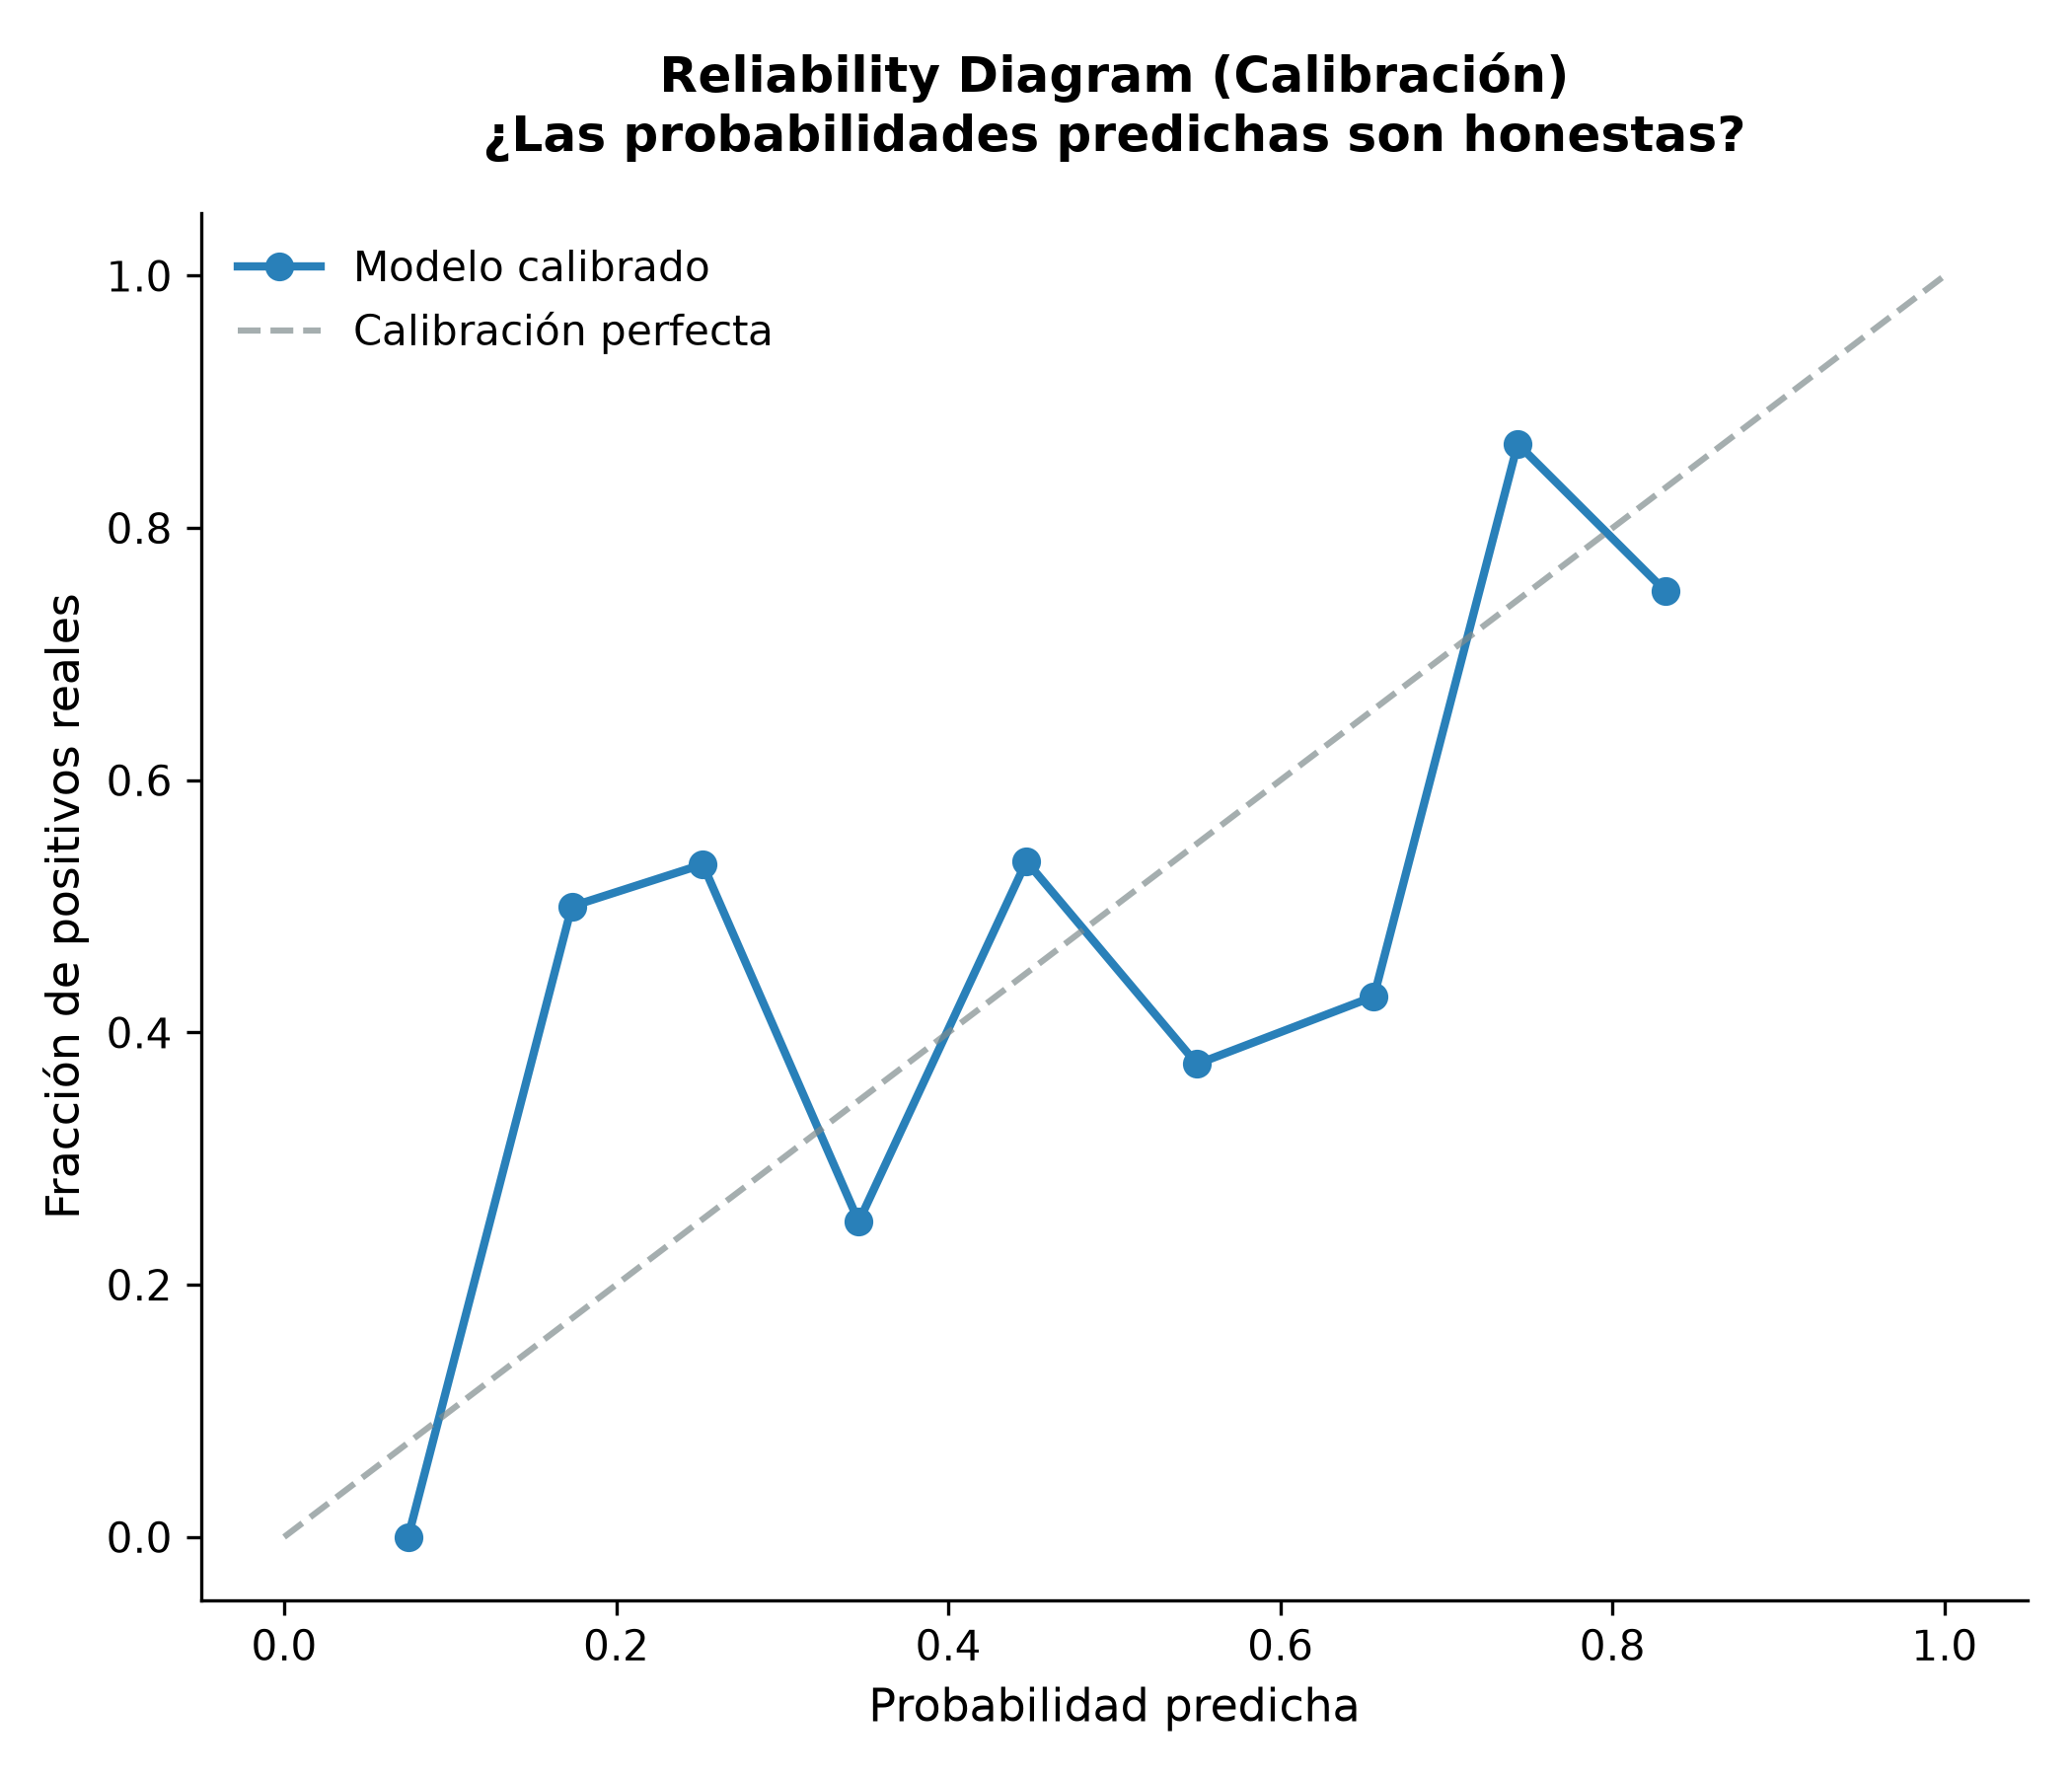

In [15]:
# Reliability diagram: ¿las probabilidades son honestas?
from src.evaluate import graficar_reliability_diagram
graficar_reliability_diagram(modelo, X_test.values, y_test)
from IPython.display import Image
Image('plots/reliability_diagram.png')

**Qué observar:** mucha masa cerca de 0.5 → el tenis es intrínsecamente difícil
de predecir. Hay *algo* de separación (las verdes pesan más a la derecha), que es
justo lo que captura el AUC ~0.62.

### 7.2 ¿Sobreajuste o falta de señal? — learning curve

Si `val_loss ≫ train_loss` y no convergen → sobreajuste. Si ambas son altas y
planas → falta señal/datos. Esto diagnostica el gap CV↔test (ítem C3).

In [16]:
from src.evaluate import graficar_learning_curve

# Genera plots/learning_curve.png reusando la utilidad del proyecto (modelo base sin calibrar)
graficar_learning_curve(modelo_base, X_train.values, y_train.values, splits)
print("Guardado en plots/learning_curve.png")

from matplotlib import image as mpimg
img = mpimg.imread("plots/learning_curve.png")
plt.figure(figsize=(8, 5)); plt.imshow(img); plt.axis("off"); plt.show()

Guardado en plots/learning_curve.png


/var/folders/hp/dy74537j7bv_kq3lbhygf4lw0000gn/T/ipykernel_14254/3316811166.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.figure(figsize=(8, 5)); plt.imshow(img); plt.axis("off"); plt.show()


**Qué observar:** train y val se acercan a medida que crecen los datos y la val
sigue bajando → el modelo está **limitado por señal/datos**, no roto por overfit.
Más datos ayudarían; el techo es la **predecibilidad intrínseca del tenis**
(~AUC 0.65–0.71 en el test grande de 2025).

---

## 8 · Conclusiones

- **ELO** convierte resultados en un rating dinámico vía expectativa logística +
  actualización proporcional a la sorpresa; el **híbrido** añade especialización
  por superficie.
- La **simetrización** es imprescindible: sin ella el label tiene fuga y el modelo
  aprende una regla trivial.
- Las **5 features** son diferencias A−B construidas desde una **fuente única**
  (`src/features.py`) para evitar train/serve skew. Se podaron h2h/forma/nivel
  (permutation importance ~0).
- El **CV temporal con embargo** da una estimación honesta; el gap residual frente
  al futuro es *distribution shift*, no leakage.
- **Modelo lineal explicable:** una regresión logística iguala a GBM/RF/XGBoost
  (la señal es lineal), y sus **coeficientes/odds-ratio** explican el peso real de
  cada feature sin necesidad de post-hoc.
- **Métricas:** mirar log-loss/Brier/AUC además de accuracy; con n pequeño usar
  **IC95% bootstrap**; comparar siempre contra el **baseline ELO** para saber si el
  modelo aporta sobre una simple resta.